Simulación de Eventos Discretos: Peluquería Maripuri
Autor: Claude
Fecha: 13 de abril de 2025

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from collections import deque
import heapq
from scipy import stats

# Configuración de visualización
plt.style.use('ggplot')
sns.set_style('whitegrid')
np.random.seed(42)

# Parámetros globales
LAMBDA = 5.0  # Tasa de llegada (clientes por hora)
MU = 6.0      # Tasa de servicio (clientes por hora) - 10 minutos por cliente
MAX_CAPACITY = 5  # 4 sillas de espera + 1 sillón de peluquería
SIM_TIME = 4000  # Tiempo de simulación en horas
WARMUP_TIME = 100  # Tiempo de calentamiento antes de empezar a recoger estadísticas
ARRIVAL, DEPARTURE = 0, 1

In [335]:
class Simulation:
    def __init__(self, arrival_rate, service_rate, max_capacity, sim_time, warmup_time):
        self.arrival_rate = arrival_rate
        self.service_rate = service_rate
        self.max_capacity = max_capacity
        self.sim_time = sim_time
        self.warmup_time = warmup_time
        
        # Estado del sistema
        self.queue = deque()  # Cola de clientes
        self.event_queue = []  # Cola de eventos (heap)
        self.current_time = 0
        self.server_busy = False
        
        # Estadísticas
        self.stats = {
            'total_customers': 0,
            'served_customers': 0,
            'rejected_customers': 0,
            'waiting_times': [],
            'system_times': [],
            'queue_lengths': [],
            'system_lengths': [],
            'utilization_times': [],
            'last_event_time': 0,
            'customers_over_45min': 0
        }
        
        # Seguimiento del estado en el tiempo para visualización
        self.time_series = []
        
        # Cliente siendo atendido actualmente
        self.current_customer = None

    def generate_interarrival_time(self):
        """Genera el tiempo entre llegadas siguiendo una distribución exponencial basada en Poisson"""
        return np.random.exponential(1.0 / self.arrival_rate)
    
    def generate_service_time(self):
        """Genera el tiempo de servicio siguiendo una distribución exponencial"""
        return np.random.exponential(1.0 / self.service_rate)
    
    def schedule_arrival(self):
        """Programa la llegada del próximo cliente"""
        interarrival_time = self.generate_interarrival_time()
        event_time = self.current_time + interarrival_time
        if event_time < self.sim_time:
            heapq.heappush(self.event_queue, (event_time, ARRIVAL))
    
    def schedule_departure(self):
        """Programa la salida del cliente que está siendo atendido"""
        service_time = self.generate_service_time()
        event_time = self.current_time + service_time
        heapq.heappush(self.event_queue, (event_time, DEPARTURE))
    
    def handle_arrival(self):
        """Maneja la llegada de un cliente"""
        self.stats['total_customers'] += 1
        
        # Programar la llegada del siguiente cliente
        self.schedule_arrival()
        
        # Si el sistema está lleno, rechazar al cliente
        if len(self.queue) + (1 if self.server_busy else 0) >= self.max_capacity:
            self.stats['rejected_customers'] += 1
            return
        
        # Crear nuevo cliente con tiempo de llegada
        customer = {
            'arrival_time': self.current_time,
            'waiting_time': 0,
            'service_time': self.generate_service_time()
        }
        
        # Si el servidor está libre, atender inmediatamente
        if not self.server_busy:
            self.server_busy = True
            self.current_customer = customer
            self.schedule_departure()
        else:
            # Si no, poner en cola
            self.queue.append(customer)
    
    def handle_departure(self):
        """Maneja la salida de un cliente"""
        self.stats['served_customers'] += 1
        
        # Calcular tiempo en el sistema para el cliente que sale
        customer = self.current_customer
        system_time = self.current_time - customer['arrival_time']
        waiting_time = system_time - customer['service_time']
        
        # Guardar estadísticas si estamos fuera del periodo de calentamiento
        if self.current_time > self.warmup_time:
            self.stats['system_times'].append(system_time)
            self.stats['waiting_times'].append(waiting_time)
            if waiting_time > 45/60:  # 45 minutos en horas
                self.stats['customers_over_45min'] += 1
        
        # Si hay clientes en cola, atender al siguiente
        if self.queue:
            self.current_customer = self.queue.popleft()
            self.schedule_departure()
        else:
            self.server_busy = False
            self.current_customer = None
    
    def update_time_statistics(self):
        """Actualiza estadísticas basadas en el tiempo transcurrido desde el último evento"""
        time_diff = self.current_time - self.stats['last_event_time']
        
        # Solo recolectar estadísticas después del periodo de calentamiento
        if self.stats['last_event_time'] > self.warmup_time:
            queue_length = len(self.queue)
            system_length = queue_length + (1 if self.server_busy else 0)
            
            self.stats['queue_lengths'].append((queue_length, time_diff))
            self.stats['system_lengths'].append((system_length, time_diff))
            self.stats['utilization_times'].append((1 if self.server_busy else 0, time_diff))
            
            # Guardar el estado actual para visualización
            self.time_series.append({
                'time': self.current_time,
                'queue_length': queue_length,
                'system_length': system_length,
                'server_busy': 1 if self.server_busy else 0
            })
        
        self.stats['last_event_time'] = self.current_time
    
    def run(self):
        """Ejecuta la simulación"""
        # Programar el primer evento (llegada)
        self.schedule_arrival()
        
        # Bucle principal de la simulación
        while self.event_queue:
            # Obtener el próximo evento
            event_time, event_type = heapq.heappop(self.event_queue)
            
            # Actualizar estadísticas antes de cambiar el tiempo
            self.update_time_statistics()
            
            # Actualizar el tiempo actual
            self.current_time = event_time
            
            # Manejar el evento
            if event_type == ARRIVAL:
                self.handle_arrival()
            else:  # DEPARTURE
                self.handle_departure()
        
        # Calcular estadísticas finales
        self.calculate_final_statistics()
    
    def calculate_final_statistics(self):
        """Calcula las estadísticas finales de la simulación"""
        # Tiempo medio de espera
        if self.stats['waiting_times']:
            self.stats['avg_waiting_time'] = np.mean(self.stats['waiting_times'])
        else:
            self.stats['avg_waiting_time'] = 0
        
        # Tiempo medio en el sistema
        if self.stats['system_times']:
            self.stats['avg_system_time'] = np.mean(self.stats['system_times'])
        else:
            self.stats['avg_system_time'] = 0
        
        # Longitud media de la cola
        total_time = sum(time for _, time in self.stats['queue_lengths'])
        if total_time > 0:
            self.stats['avg_queue_length'] = sum(length * time for length, time in self.stats['queue_lengths']) / total_time
        else:
            self.stats['avg_queue_length'] = 0
        
        # Longitud media del sistema
        total_time = sum(time for _, time in self.stats['system_lengths'])
        if total_time > 0:
            self.stats['avg_system_length'] = sum(length * time for length, time in self.stats['system_lengths']) / total_time
        else:
            self.stats['avg_system_length'] = 0
        
        # Utilización del servidor
        total_time = sum(time for _, time in self.stats['utilization_times'])
        if total_time > 0:
            self.stats['server_utilization'] = sum(util * time for util, time in self.stats['utilization_times']) / total_time
        else:
            self.stats['server_utilization'] = 0
        
        # Probabilidad de rechazo (no encontrar sitio)
        if self.stats['total_customers'] > 0:
            self.stats['rejection_probability'] = self.stats['rejected_customers'] / self.stats['total_customers']
        else:
            self.stats['rejection_probability'] = 0
            
        # Probabilidad de esperar más de 45 minutos
        if len(self.stats['waiting_times']) > 0:
            self.stats['prob_wait_over_45min'] = self.stats['customers_over_45min'] / len(self.stats['waiting_times'])
        else:
            self.stats['prob_wait_over_45min'] = 0
    
    def create_time_series_df(self):
        """Crea un DataFrame con la serie temporal de los estados del sistema"""
        return pd.DataFrame(self.time_series)
    
    def print_summary(self):
        """Imprime un resumen de los resultados de la simulación"""
        print("\n===== RESULTADOS DE LA SIMULACIÓN =====")
        print(f"Tiempo total de simulación: {self.sim_time} horas (con {self.warmup_time} horas de calentamiento)")
        print(f"Tasa de llegada: {self.arrival_rate} clientes/hora")
        print(f"Tasa de servicio: {self.service_rate} clientes/hora")
        print(f"Capacidad máxima: {self.max_capacity} clientes")
        print("\n--- Estadísticas ---")
        print(f"Clientes totales que llegaron: {self.stats['total_customers']}")
        print(f"Clientes atendidos: {self.stats['served_customers']}")
        print(f"Clientes rechazados: {self.stats['rejected_customers']}")
        print(f"Probabilidad de rechazo: {self.stats['rejection_probability']:.4f}")
        print(f"\nNúmero medio de clientes en el salón: {self.stats['avg_system_length']:.4f}")
        print(f"Número medio de clientes esperando: {self.stats['avg_queue_length']:.4f}")
        print(f"Tiempo medio de espera: {self.stats['avg_waiting_time']*60:.2f} minutos")
        print(f"Tiempo medio en el sistema: {self.stats['avg_system_time']*60:.2f} minutos")
        print(f"Utilización del servidor: {self.stats['server_utilization']*100:.2f}%")
        print(f"Probabilidad de esperar más de 45 minutos: {self.stats['prob_wait_over_45min']:.4f}")


In [336]:
# Ejecutar la simulación
sim = Simulation(LAMBDA, MU, MAX_CAPACITY, SIM_TIME, WARMUP_TIME)
sim.run()
sim.print_summary()


===== RESULTADOS DE LA SIMULACIÓN =====
Tiempo total de simulación: 4000 horas (con 100 horas de calentamiento)
Tasa de llegada: 10.0 clientes/hora
Tasa de servicio: 15.0 clientes/hora
Capacidad máxima: 5 clientes

--- Estadísticas ---
Clientes totales que llegaron: 40205
Clientes atendidos: 38285
Clientes rechazados: 1920
Probabilidad de rechazo: 0.0478

Número medio de clientes en el salón: 1.6272
Número medio de clientes esperando: 0.7741
Tiempo medio de espera: 4.80 minutos
Tiempo medio en el sistema: 8.82 minutos
Utilización del servidor: 85.32%
Probabilidad de esperar más de 45 minutos: 0.0009


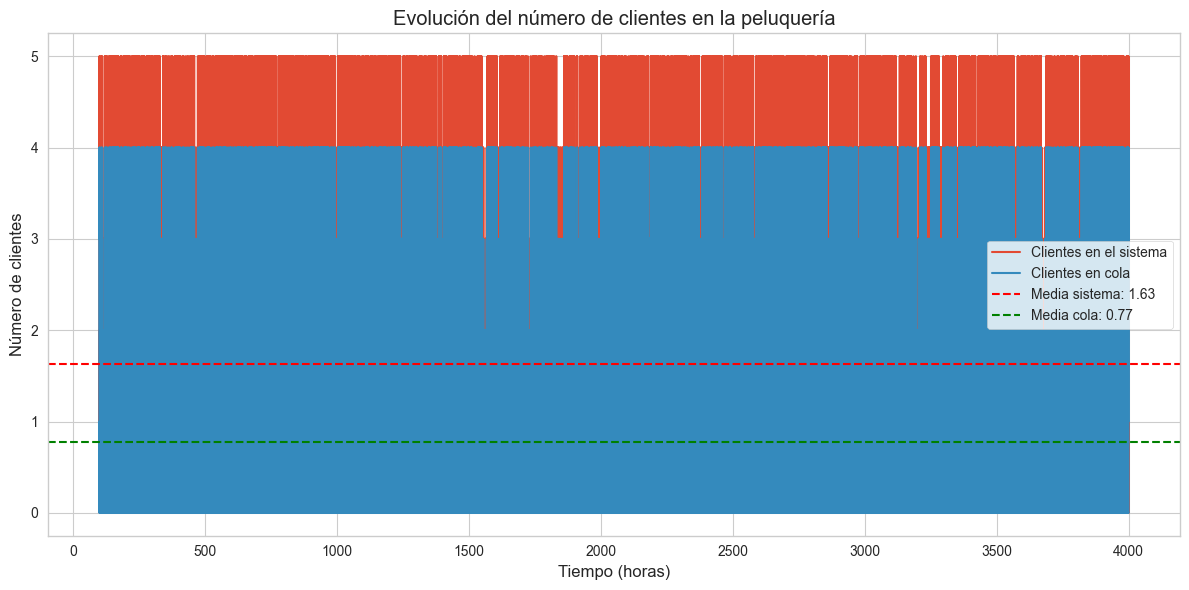

In [337]:
# Gráficos para analizar los resultados
time_series_df = sim.create_time_series_df()
plt.figure(figsize=(12, 6))
plt.plot(time_series_df['time'], time_series_df['system_length'], label='Clientes en el sistema')
plt.plot(time_series_df['time'], time_series_df['queue_length'], label='Clientes en cola')
plt.axhline(y=sim.stats['avg_system_length'], color='r', linestyle='--', label=f'Media sistema: {sim.stats["avg_system_length"]:.2f}')
plt.axhline(y=sim.stats['avg_queue_length'], color='g', linestyle='--', label=f'Media cola: {sim.stats["avg_queue_length"]:.2f}')
plt.xlabel('Tiempo (horas)')
plt.ylabel('Número de clientes')
plt.title('Evolución del número de clientes en la peluquería')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

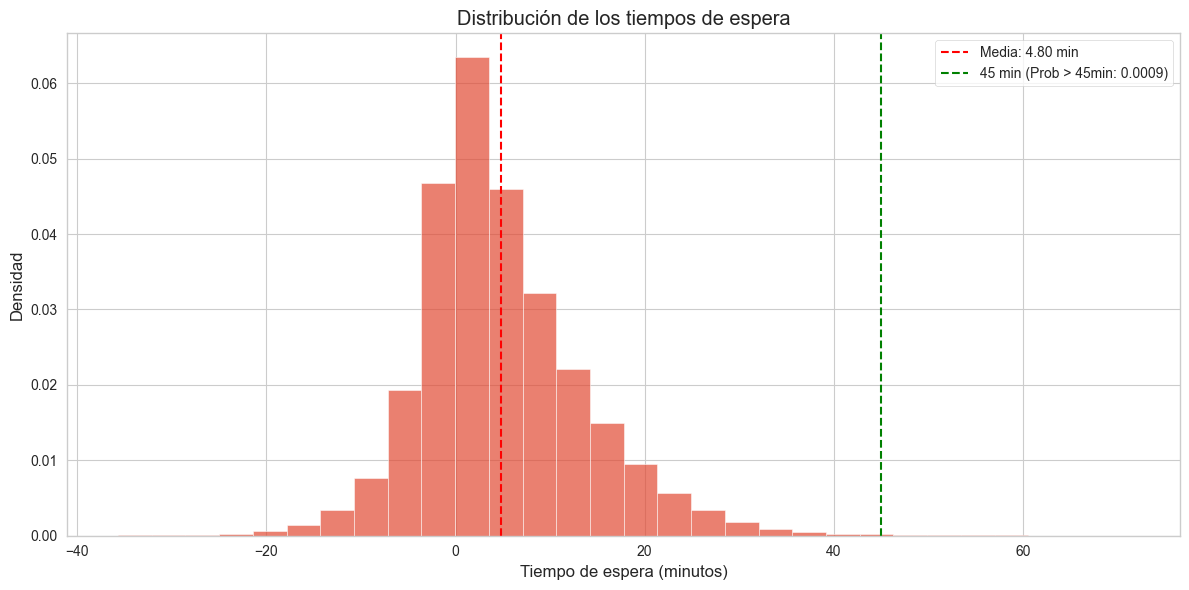

In [338]:
# 2. Distribución de tiempos de espera
waiting_times_min = np.array(sim.stats['waiting_times']) * 60  # Convertir a minutos
plt.figure(figsize=(12, 6))
plt.hist(waiting_times_min, bins=30, alpha=0.7, density=True)
plt.axvline(x=np.mean(waiting_times_min), color='r', linestyle='--', 
           label=f'Media: {np.mean(waiting_times_min):.2f} min')
plt.axvline(x=45, color='g', linestyle='--', 
           label=f'45 min (Prob > 45min: {sim.stats["prob_wait_over_45min"]:.4f})')
plt.xlabel('Tiempo de espera (minutos)')
plt.ylabel('Densidad')
plt.title('Distribución de los tiempos de espera')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

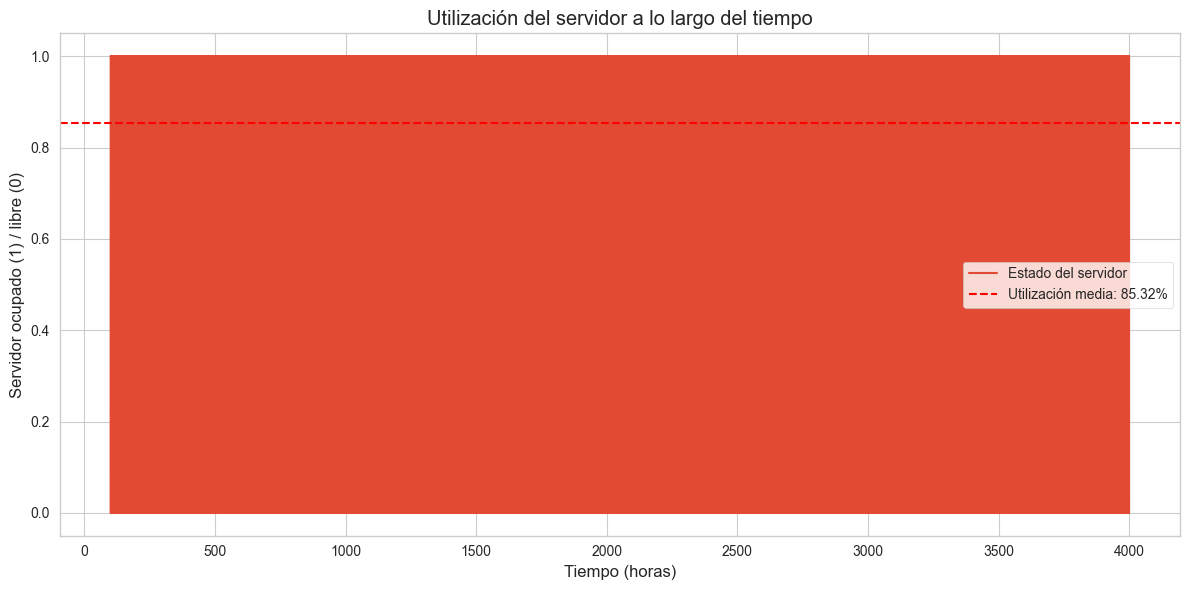

In [339]:
# 3. Utilización del servidor a lo largo del tiempo
plt.figure(figsize=(12, 6))
plt.plot(time_series_df['time'], time_series_df['server_busy'], label='Estado del servidor')
plt.axhline(y=sim.stats['server_utilization'], color='r', linestyle='--', 
           label=f'Utilización media: {sim.stats["server_utilization"]*100:.2f}%')
plt.xlabel('Tiempo (horas)')
plt.ylabel('Servidor ocupado (1) / libre (0)')
plt.title('Utilización del servidor a lo largo del tiempo')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Análisis de parada de la simulación
Vamos a ejecutar múltiples simulaciones de diferentes duraciones para ver cuándo convergen los resultados

In [340]:
def run_multiple_simulations(durations):
    """Ejecuta múltiples simulaciones con diferentes duraciones"""
    results = []
    for duration in durations:
        # Crear y ejecutar simulación
        s = Simulation(LAMBDA, MU, MAX_CAPACITY, duration, min(duration*0.1, 100))
        s.run()
        
        # Almacenar resultados
        results.append({
            'duration': duration,
            'avg_system_length': s.stats['avg_system_length'],
            'avg_queue_length': s.stats['avg_queue_length'],
            'server_utilization': s.stats['server_utilization'],
            'rejection_probability': s.stats['rejection_probability'],
            'prob_wait_over_45min': s.stats['prob_wait_over_45min']
        })
    
    return pd.DataFrame(results)


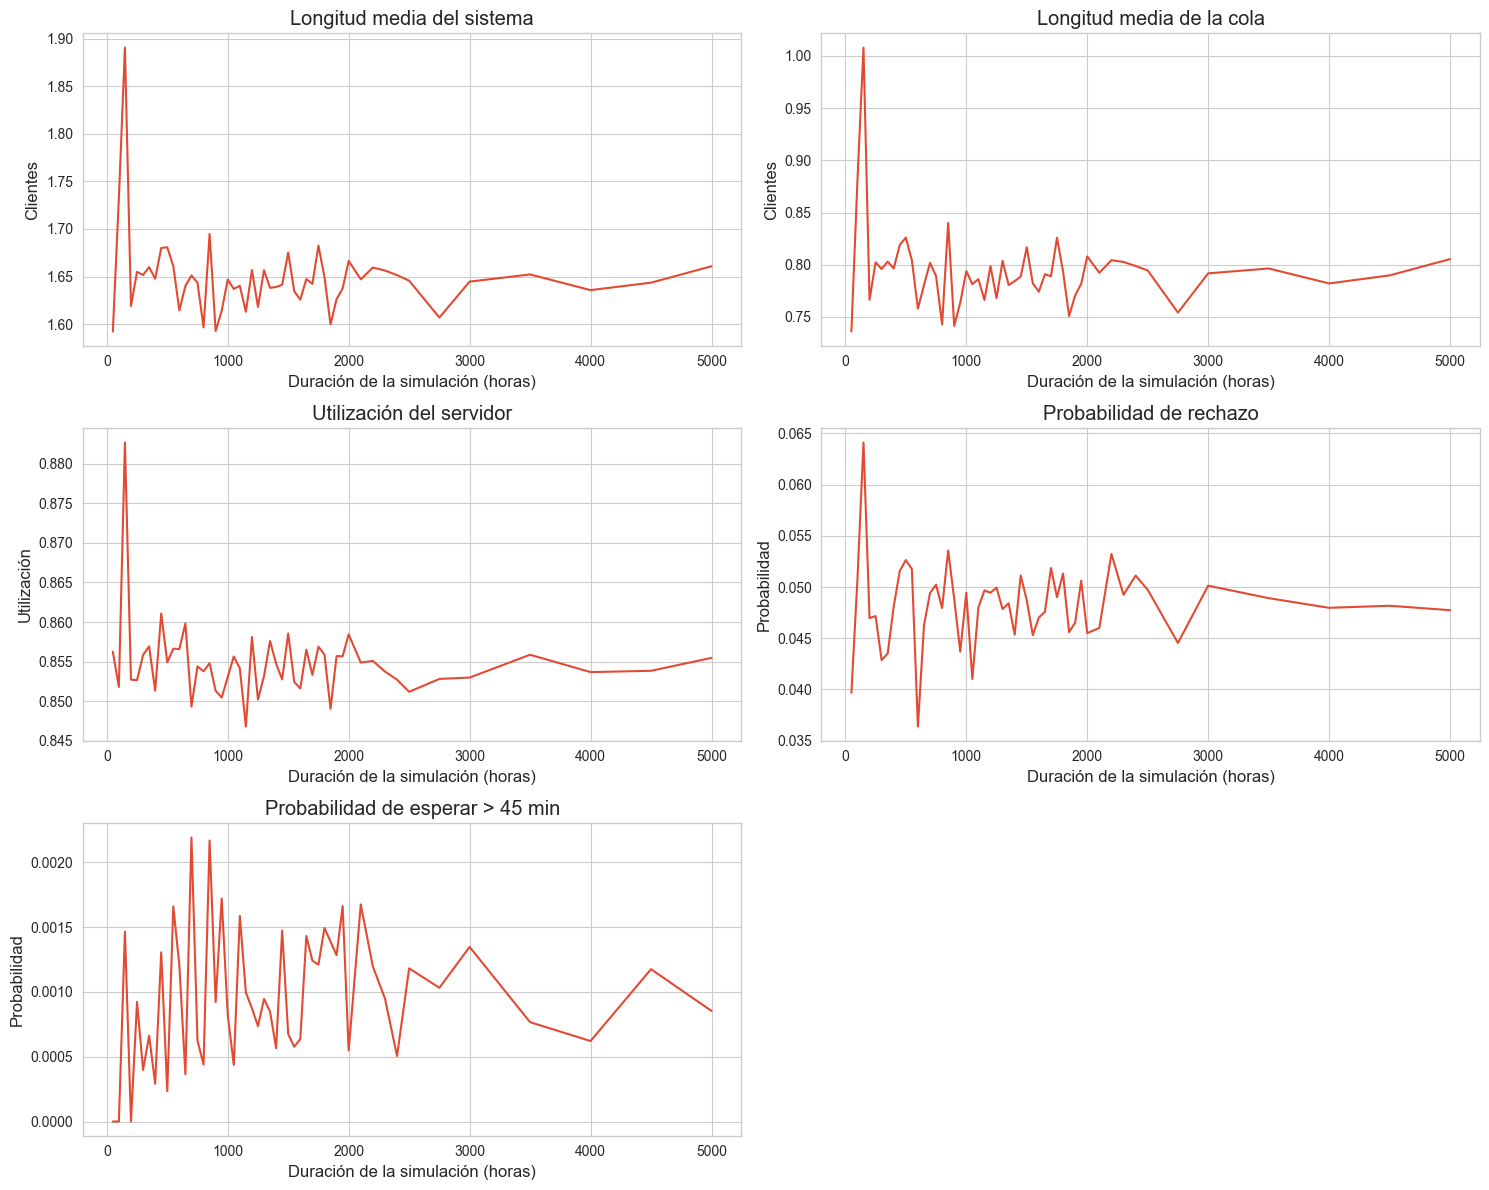

In [341]:
# Visualizar la convergencia
durations = [
    50, 100, 150, 200, 250, 300, 350, 400, 450, 500,
    550, 600, 650, 700, 750, 800, 850, 900, 950, 1000,
    1050, 1100, 1150, 1200, 1250, 1300, 1350, 1400, 1450, 1500,
    1550, 1600, 1650, 1700, 1750, 1800, 1850, 1900, 1950, 2000,
    2100, 2200, 2300, 2400, 2500, 2750, 3000, 3500, 4000, 4500, 
    5000
]
convergence_results = run_multiple_simulations(durations)

# Visualizar la convergencia
fig, axs = plt.subplots(3, 2, figsize=(15, 12))

axs[0, 0].plot(convergence_results['duration'], convergence_results['avg_system_length'])
axs[0, 0].set_title('Longitud media del sistema')
axs[0, 0].set_xlabel('Duración de la simulación (horas)')
axs[0, 0].set_ylabel('Clientes')
axs[0, 0].grid(True)

axs[0, 1].plot(convergence_results['duration'], convergence_results['avg_queue_length'])
axs[0, 1].set_title('Longitud media de la cola')
axs[0, 1].set_xlabel('Duración de la simulación (horas)')
axs[0, 1].set_ylabel('Clientes')
axs[0, 1].grid(True)

axs[1, 0].plot(convergence_results['duration'], convergence_results['server_utilization'])
axs[1, 0].set_title('Utilización del servidor')
axs[1, 0].set_xlabel('Duración de la simulación (horas)')
axs[1, 0].set_ylabel('Utilización')
axs[1, 0].grid(True)

axs[1, 1].plot(convergence_results['duration'], convergence_results['rejection_probability'])
axs[1, 1].set_title('Probabilidad de rechazo')
axs[1, 1].set_xlabel('Duración de la simulación (horas)')
axs[1, 1].set_ylabel('Probabilidad')
axs[1, 1].grid(True)

axs[2, 0].plot(convergence_results['duration'], convergence_results['prob_wait_over_45min'])
axs[2, 0].set_title('Probabilidad de esperar > 45 min')
axs[2, 0].set_xlabel('Duración de la simulación (horas)')
axs[2, 0].set_ylabel('Probabilidad')
axs[2, 0].grid(True)

axs[2, 1].axis('off')  # No usar este subplot

plt.tight_layout()
plt.show()


In [342]:
# Modelo analítico: M/M/1/K (Poisson llegadas, Exponencial servicios, 1 servidor, K capacidad)
def mm1k_model(lambda_rate, mu_rate, k):
    """Calcular métricas para un sistema M/M/1/K"""
    rho = lambda_rate / mu_rate  # Tasa de utilización
    
    if rho == 1:
        # Caso especial cuando rho = 1
        p0 = 1 / (k + 1)
        L = k / 2
        Lq = L - (1 - p0)
        W = L / (lambda_rate * (1 - pk))
        Wq = Lq / (lambda_rate * (1 - pk))
        pk = p0
    else:
        # Caso general
        p0 = (1 - rho) / (1 - rho**(k+1))
        pk = p0 * rho**k
        L = rho * (1 - (k+1) * rho**k + k * rho**(k+1)) / ((1 - rho) * (1 - rho**(k+1)))
        Lq = L - (1 - pk)
        
        # Tasa efectiva de llegada (clientes aceptados)
        lambda_eff = lambda_rate * (1 - pk)
        
        # Tiempo medio en el sistema y en cola
        W = L / lambda_eff if lambda_eff > 0 else float('inf')
        Wq = Lq / lambda_eff if lambda_eff > 0 else float('inf')
    
    # Probabilidad de esperar más de t tiempo
    def prob_wait_more_than(t):
        if Lq == 0:
            return 0
        return (1 - pk) * np.exp(-mu_rate * (1 - rho) * t)
    
    return {
        'rho': rho,
        'p0': p0,  # Prob. sistema vacío
        'pk': pk,  # Prob. sistema lleno
        'L': L,    # Clientes medios en sistema
        'Lq': Lq,  # Clientes medios en cola
        'W': W,    # Tiempo medio en sistema
        'Wq': Wq,  # Tiempo medio en cola
        'prob_wait_more_than_45min': prob_wait_more_than(45/60)  # Prob. esperar más de 45 min
    }

In [343]:
# Calcular resultados teóricos
model_results = mm1k_model(LAMBDA, MU, MAX_CAPACITY)

In [344]:
# Comparar resultados teóricos con simulación
print("\n===== COMPARACIÓN MODELO TEÓRICO VS SIMULACIÓN =====")
print(f"Modelo teórico M/M/1/{MAX_CAPACITY}")
print(f"Utilización teórica del servidor: {model_results['rho']:.4f}")
print(f"Utilización simulada del servidor: {sim.stats['server_utilization']:.4f}")
print(f"Número medio teórico de clientes en el sistema: {model_results['L']:.4f}")
print(f"Número medio simulado de clientes en el sistema: {sim.stats['avg_system_length']:.4f}")
print(f"Número medio teórico de clientes en cola: {model_results['Lq']:.4f}")
print(f"Número medio simulado de clientes en cola: {sim.stats['avg_queue_length']:.4f}")
print(f"Probabilidad teórica de sistema lleno: {model_results['pk']:.4f}")
print(f"Probabilidad simulada de rechazo: {sim.stats['rejection_probability']:.4f}")
print(f"Probabilidad teórica de esperar > 45 min: {model_results['prob_wait_more_than_45min']:.4f}")
print(f"Probabilidad simulada de esperar > 45 min: {sim.stats['prob_wait_over_45min']:.4f}")


===== COMPARACIÓN MODELO TEÓRICO VS SIMULACIÓN =====
Modelo teórico M/M/1/5
Utilización teórica del servidor: 0.6667
Utilización simulada del servidor: 0.8532
Número medio teórico de clientes en el sistema: 1.4226
Número medio simulado de clientes en el sistema: 1.6272
Número medio teórico de clientes en cola: 0.4707
Número medio simulado de clientes en cola: 0.7741
Probabilidad teórica de sistema lleno: 0.0481
Probabilidad simulada de rechazo: 0.0478
Probabilidad teórica de esperar > 45 min: 0.0224
Probabilidad simulada de esperar > 45 min: 0.0009


In [345]:
# Análisis de sensibilidad: Efecto de contratar una ayudante
# Suponemos que con una ayudante la tasa de servicio se duplica
def sensitivity_analysis():
    """Analiza el efecto de diferentes tasas de servicio"""
    # Tasas de servicio a probar (clientes por hora)
    service_rates = [6, 8, 10, 12]  # 10, 7.5, 6, 5 minutos por cliente
    
    results = []
    for rate in service_rates:
        # Crear y ejecutar simulación
        s = Simulation(LAMBDA, rate, MAX_CAPACITY, SIM_TIME, WARMUP_TIME)
        s.run()
        
        # Calcular resultados teóricos
        model = mm1k_model(LAMBDA, rate, MAX_CAPACITY)
        
        # Almacenar resultados
        results.append({
            'service_rate': rate,
            'service_time_min': 60/rate,
            'sim_avg_system_length': s.stats['avg_system_length'],
            'sim_avg_queue_length': s.stats['avg_queue_length'],
            'sim_server_utilization': s.stats['server_utilization'],
            'sim_rejection_probability': s.stats['rejection_probability'],
            'sim_prob_wait_over_45min': s.stats['prob_wait_over_45min'],
            'model_L': model['L'],
            'model_Lq': model['Lq'],
            'model_pk': model['pk'],
            'model_prob_wait_over_45min': model['prob_wait_more_than_45min']
        })
    
    return pd.DataFrame(results)

In [346]:
sensitivity_results = sensitivity_analysis()

UnboundLocalError: local variable 'pk' referenced before assignment

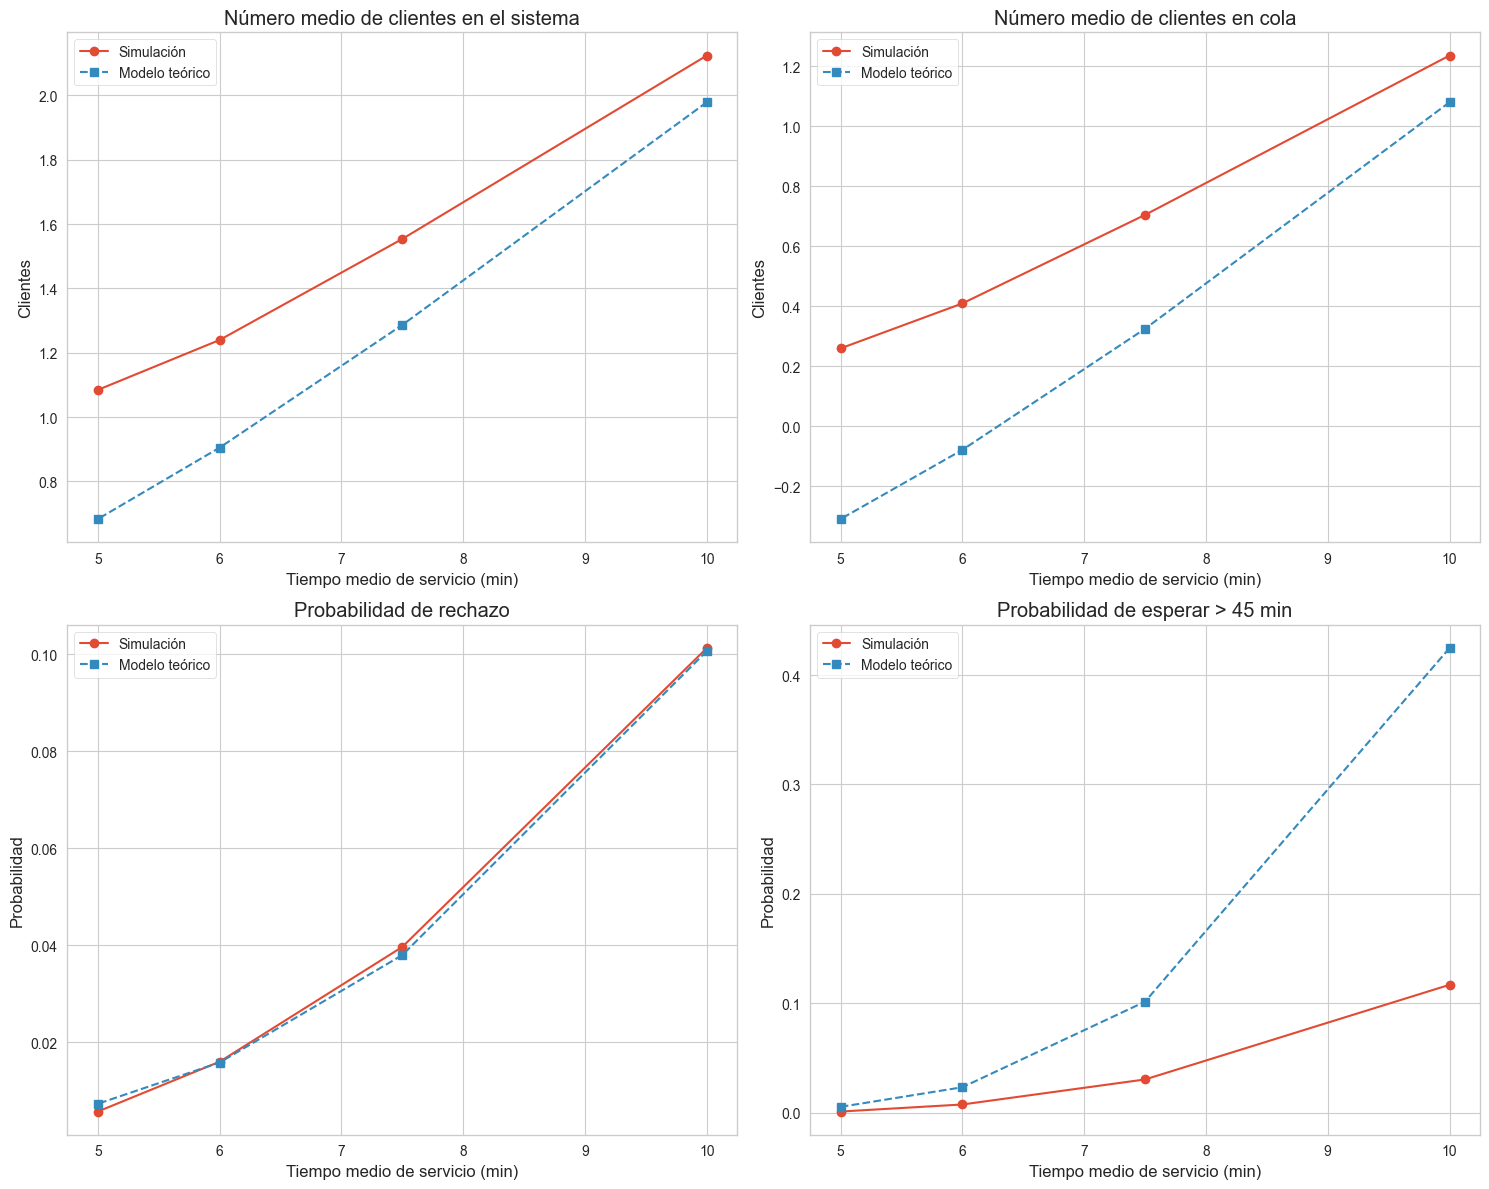

In [ ]:
# Visualizar los resultados del análisis de sensibilidad
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

axs[0, 0].plot(sensitivity_results['service_time_min'], sensitivity_results['sim_avg_system_length'], 
              'o-', label='Simulación')
axs[0, 0].plot(sensitivity_results['service_time_min'], sensitivity_results['model_L'], 
              's--', label='Modelo teórico')
axs[0, 0].set_title('Número medio de clientes en el sistema')
axs[0, 0].set_xlabel('Tiempo medio de servicio (min)')
axs[0, 0].set_ylabel('Clientes')
axs[0, 0].legend()
axs[0, 0].grid(True)

axs[0, 1].plot(sensitivity_results['service_time_min'], sensitivity_results['sim_avg_queue_length'], 
              'o-', label='Simulación')
axs[0, 1].plot(sensitivity_results['service_time_min'], sensitivity_results['model_Lq'], 
              's--', label='Modelo teórico')
axs[0, 1].set_title('Número medio de clientes en cola')
axs[0, 1].set_xlabel('Tiempo medio de servicio (min)')
axs[0, 1].set_ylabel('Clientes')
axs[0, 1].legend()
axs[0, 1].grid(True)

axs[1, 0].plot(sensitivity_results['service_time_min'], sensitivity_results['sim_rejection_probability'], 
              'o-', label='Simulación')
axs[1, 0].plot(sensitivity_results['service_time_min'], sensitivity_results['model_pk'], 
              's--', label='Modelo teórico')
axs[1, 0].set_title('Probabilidad de rechazo')
axs[1, 0].set_xlabel('Tiempo medio de servicio (min)')
axs[1, 0].set_ylabel('Probabilidad')
axs[1, 0].legend()
axs[1, 0].grid(True)

axs[1, 1].plot(sensitivity_results['service_time_min'], sensitivity_results['sim_prob_wait_over_45min'], 
              'o-', label='Simulación')
axs[1, 1].plot(sensitivity_results['service_time_min'], sensitivity_results['model_prob_wait_over_45min'], 
              's--', label='Modelo teórico')
axs[1, 1].set_title('Probabilidad de esperar > 45 min')
axs[1, 1].set_xlabel('Tiempo medio de servicio (min)')
axs[1, 1].set_ylabel('Probabilidad')
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Tabla resumen de resultados del análisis de sensibilidad
print("\n===== ANÁLISIS DE SENSIBILIDAD: EFECTO DE CONTRATAR UNA AYUDANTE =====")
print("Comparación de diferentes tiempos medios de servicio:")
print(sensitivity_results[['service_time_min', 'sim_avg_system_length', 'sim_avg_queue_length', 
                           'sim_rejection_probability', 'sim_prob_wait_over_45min']])


===== ANÁLISIS DE SENSIBILIDAD: EFECTO DE CONTRATAR UNA AYUDANTE =====
Comparación de diferentes tiempos medios de servicio:
   service_time_min  sim_avg_system_length  sim_avg_queue_length  \
0              10.0               2.123958              1.235314   
1               7.5               1.553675              0.704086   
2               6.0               1.239509              0.408874   
3               5.0               1.084274              0.258970   

   sim_rejection_probability  sim_prob_wait_over_45min  
0                   0.101319                  0.116821  
1                   0.039711                  0.030266  
2                   0.016040                  0.007380  
3                   0.005764                  0.000922  


In [ ]:
# Conclusiones
print("\n===== CONCLUSIONES =====")
print("1. En el escenario actual (10 min/cliente):")
print(f"   - Número medio de clientes en el salón: {sim.stats['avg_system_length']:.2f}")
print(f"   - Número medio de clientes esperando: {sim.stats['avg_queue_length']:.2f}")
print(f"   - Probabilidad de no encontrar sitio: {sim.stats['rejection_probability']:.4f}")
print(f"   - Probabilidad de esperar más de 45 min: {sim.stats['prob_wait_over_45min']:.4f}")


===== CONCLUSIONES =====
1. En el escenario actual (10 min/cliente):
   - Número medio de clientes en el salón: 2.13
   - Número medio de clientes esperando: 1.24
   - Probabilidad de no encontrar sitio: 0.1023
   - Probabilidad de esperar más de 45 min: 0.1150


In [ ]:
# Obtener valores para el escenario con ayudante (5 min/cliente)
helper_scenario = sensitivity_results[sensitivity_results['service_time_min'] == 5].iloc[0] if 5 in sensitivity_results['service_time_min'].values else None

In [ ]:
if helper_scenario is not None:
    print("\n2. En el escenario con ayudante (5 min/cliente):")
    print(f"   - Número medio de clientes en el salón: {helper_scenario['sim_avg_system_length']:.2f}")
    print(f"   - Número medio de clientes esperando: {helper_scenario['sim_avg_queue_length']:.2f}")
    print(f"   - Probabilidad de no encontrar sitio: {helper_scenario['sim_rejection_probability']:.4f}")
    print(f"   - Probabilidad de esperar más de 45 min: {helper_scenario['sim_prob_wait_over_45min']:.4f}")


2. En el escenario con ayudante (5 min/cliente):
   - Número medio de clientes en el salón: 1.08
   - Número medio de clientes esperando: 0.26
   - Probabilidad de no encontrar sitio: 0.0058
   - Probabilidad de esperar más de 45 min: 0.0009


In [ ]:
print("\n3. Recomendación:")
if helper_scenario is not None and helper_scenario['sim_avg_queue_length'] < 1.0 and helper_scenario['sim_prob_wait_over_45min'] < 0.1:
    print("   Se recomienda contratar una ayudante, ya que reduciría significativamente los tiempos de espera y la probabilidad de no encontrar sitio.")
else:
    print("   Se requiere un análisis económico adicional para determinar si el beneficio de contratar una ayudante justifica el costo.")


3. Recomendación:
   Se recomienda contratar una ayudante, ya que reduciría significativamente los tiempos de espera y la probabilidad de no encontrar sitio.
